In [606]:
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from src.models.retinanet import RetinaNet
from src.io import load_model_weights
from src.dataset import get_datasets, get_titanium_datasets, titanium_collate_fn, LunarCraterDataset
from src.utils import masks_list_to_targets_list

In [607]:
MEAN=(0.485, 0.456, 0.406)
STD=(0.229, 0.224, 0.225)

In [608]:
train_dataset, test_dataset = get_datasets("our_dataset", n_att=5)

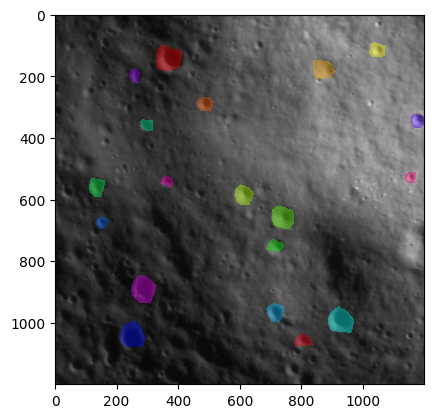

In [609]:
train_dataset.view(0)

In [610]:
targets = masks_list_to_targets_list(train_dataset[0][1].unsqueeze(0))[0]
targets

{'boxes': tensor([[ 327.,   97.,  410.,  184.],
         [ 457.,  267.,  513.,  316.],
         [ 838.,  150.,  909.,  210.],
         [1018.,   90., 1072.,  140.],
         [ 582.,  551.,  644.,  619.],
         [ 702.,  623.,  775.,  698.],
         [ 686.,  729.,  742.,  770.],
         [ 110.,  531.,  162.,  594.],
         [ 276.,  339.,  317.,  380.],
         [ 884.,  946.,  968., 1033.],
         [ 683.,  936.,  743., 1001.],
         [ 128.,  658.,  172.,  695.],
         [ 209.,  994.,  295., 1079.],
         [1152.,  322., 1199.,  370.],
         [ 238.,  176.,  277.,  225.],
         [ 245.,  846.,  327.,  938.],
         [ 341.,  523.,  384.,  563.],
         [1136.,  512., 1170.,  546.],
         [ 776., 1037.,  837., 1078.]]),
 'labels': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}

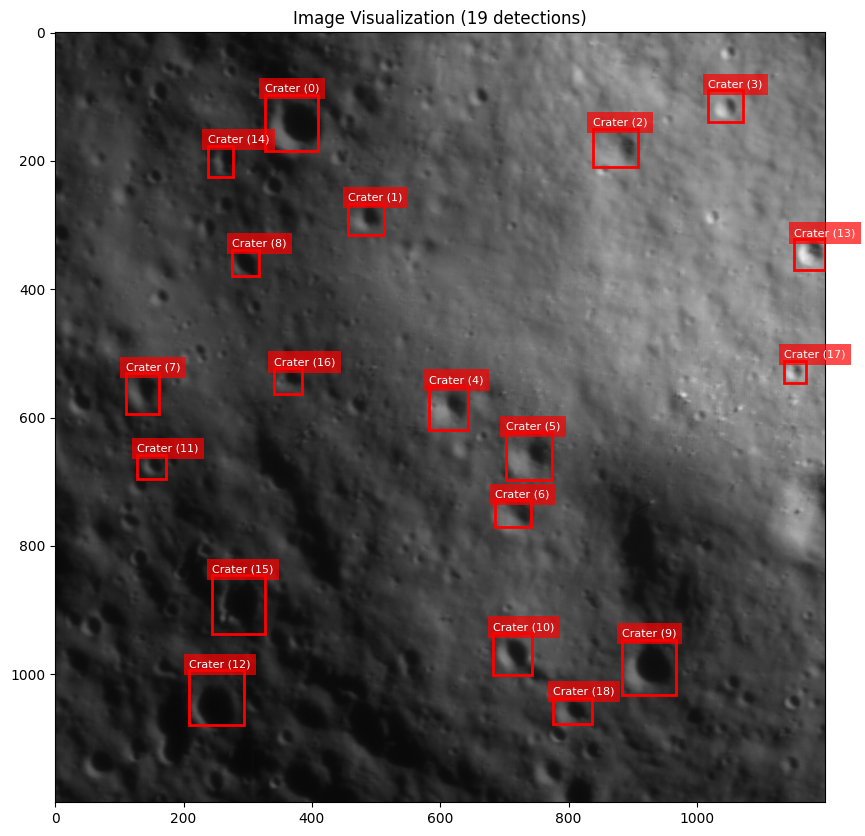

In [611]:
LunarCraterDataset.view_bbox(train_dataset[0][0], targets)

In [612]:
model = RetinaNet(state_dict=load_model_weights("saved_weights", "annotator_weights.pth")).to("cuda")
model.eval()


Model weights successfully loaded from: saved_weights/annotator_weights.pth


RetinaNet(
  (model): RetinaNet(
    (backbone): BackboneWithFPN(
      (body): IntermediateLayerGetter(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (layer1): Sequential(
          (0): Bottleneck(
            (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn3): BatchNorm2d(256, eps=1e-05, momentum=

In [613]:
device = "cuda"

In [614]:
output = None
with torch.inference_mode():
    output = model(train_dataset[0][0].unsqueeze(0).to(device))

In [615]:
output = output[0]

In [616]:
output.keys()

dict_keys(['boxes', 'scores', 'labels'])

In [617]:
SCORE_THRESH = 0.2

In [618]:
output_mask = output["scores"] >= SCORE_THRESH
output = {
    "boxes": output["boxes"][output_mask].to(device),
    "labels": torch.tensor(list(range(len(output_mask)))).to(device),
    "scores": output["scores"][output_mask].to(device)
}

In [619]:
def visualize_detection(image_tensor, targets_dict, mean=MEAN, std=STD, class_name="Crater"):
    """
    Denormalizes an image tensor and displays it with ground truth bounding boxes.

    Args:
        image_tensor (torch.Tensor): Normalized image tensor (C, H, W).
        targets_dict (dict): Dictionary containing 'boxes' (N, 4) in [x1, y1, x2, y2]
                             and 'labels' (N,).
        mean (tuple): Mean values used for normalization.
        std (tuple): Standard deviation values used for normalization.
        class_name (str): Name of the detected class (Crater).
    """
    
    # 1. Denormalize and Convert Tensor to NumPy Array (H, W, C)
    
    # Reverse Normalization: value = (normalized_value * std) + mean
    # We use a custom lambda transform to ensure the process is correctly applied channel-wise
    
    denormalize = transforms.Normalize(
        mean=[-m/s for m, s in zip(mean, std)], 
        std=[1/s for s in std]
    )
    
    img_array = denormalize(image_tensor).cpu().numpy().transpose(1, 2, 0)
    
    # Clamp values to the valid [1] range in case of floating point inaccuracies
    img_array = np.clip(img_array, 0, 1)

    # 2. Extract Bounding Boxes
    # RetinaNet targets use absolute pixel coordinates [x1, y1, x2, y2] [2].
    boxes = targets_dict['boxes'].cpu().numpy()
    labels = targets_dict['labels'].cpu().numpy()
    scores = targets_dict['scores'].cpu().numpy()
    
    # Get image dimensions (after resizing applied in the dataset)
    H, W, C = img_array.shape

    # 3. Plotting
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img_array)
    
    for box, label, score in zip(boxes, labels, scores):
        # Coordinates are [x1, y1, x2, y2]
        x_min, y_min, x_max, y_max = box
        
        # Calculate width and height for Matplotlib patch
        width = x_max - x_min
        height = y_max - y_min
        
        # Create a Rectangle patch (start point is (x_min, y_min))
        rect = patches.Rectangle(
            (x_min, y_min), 
            width, 
            height,
            linewidth=2,
            edgecolor='r',
            facecolor='none'
        )
        
        # Add the patch to the Axes
        ax.add_patch(rect)
        
        # Add label text (Crater, since category_id=1 [3] corresponds to the first class)
        ax.text(
            x_min, y_min - 5, # Position slightly above the box
            f'{label}: {score:.2f}',
            color='white',
            fontsize=8,
            bbox=dict(facecolor='red', alpha=0.7, edgecolor='none')
        )

    ax.set_title(f"Image Visualization ({len(boxes)} detections)")
    plt.show()

In [ ]:
from torchvision.ops import complete_box_iou

def remove_duplicates(targets, iou_threshold=-0.1):
    """complete_box_iou
    Remove duplicate bounding boxes based on IoU threshold.

    Args:
        targets (dict): Dictionary containing 'boxes' (N, 4) and 'labels' (N,).
        iou_threshold (float): IoU threshold to consider boxes as duplicates.

    Returns:
        dict: Dictionary with unique 'boxes' and 'labels'.
    """

    boxes = targets["boxes"]
    labels = targets["labels"]
    scores = targets["scores"]

    # sort boxes by scores in descending order
    sorted_indices = torch.argsort(scores, descending=True)
    boxes = boxes[sorted_indices]
    labels = labels[sorted_indices]
    scores = scores[sorted_indices]

    if len(boxes) == 0:
        return targets

    # Compute IoU between all pairs of boxes
    iou_matrix = complete_box_iou(boxes, boxes)

    # Create a mask to keep track of which boxes to keep
    keep_mask = torch.ones(len(boxes), dtype=torch.bool)

    # remove iou duplicates
    for i in range(len(boxes)):
        if not keep_mask[i]:
            continue
        # Mark boxes that have high IoU with the current box as duplicates
        for j in range(len(boxes)):
            if i != j and iou_matrix[i, j] > iou_threshold:
                keep_mask[j] = False

    # remove boxes that cover other boxes (if box A covers box B, we keep the one with the higher score)
    for i in range(len(boxes)):
        if not keep_mask[i]:
            continue
        for j in range(len(boxes)):
            if i != j and keep_mask[j]:
                # Check if box i covers box j
                if (boxes[i, 0] <= boxes[j, 0] and boxes[i, 1] <= boxes[j, 1] and
                    boxes[i, 2] >= boxes[j, 2] and boxes[i, 3] >= boxes[j, 3]):
                    # If box i has a higher score than box j, we keep box i and remove box j
                    if scores[i] >= scores[j]:
                        keep_mask[j] = False
                    else:
                        keep_mask[i] = False
                        break

    # Filter out duplicates
    unique_boxes = boxes[keep_mask]
    # new_labels = torch.tensor(list(range(len(unique_boxes))))
    new_labels = labels[keep_mask]
    unique_scores = scores[keep_mask]

    return {'boxes': unique_boxes, 'labels': new_labels, 'scores': unique_scores}, iou_matrix
    

In [621]:
def inflate_annots(targets, height, width, height_factor, width_factor):
    """
    Inflates bounding boxes by a specified factor.

    Args:
        targets (dict): Dictionary containing 'boxes' (N, 4) and 'labels' (N,).
        height (int): Height of the image.
        width (int): Width of the image.
        height_factor (float): Factor by which to inflate each side of the box in height.
        width_factor (float): Factor by which to inflate each side of the box in width.
    Returns:
        dict: Dictionary with inflated 'boxes' and original 'labels'.
    """
    boxes = targets["boxes"]

    inflated_boxes = []

    # Inflate boxes
    for box in boxes:
        x_min, y_min, x_max, y_max = box

        # Inflate the box by the specified factor
        box_width = x_max - x_min
        box_height = y_max - y_min

        x_min = max(0, x_min - width_factor * box_width)
        y_min = max(0, y_min - height_factor * box_height)
        x_max = min(width, x_max + width_factor * box_width)
        y_max = min(height, y_max + height_factor * box_height)

        # Update the box with new coordinates
        inflated_boxes.append([x_min, y_min, x_max, y_max])
    
    inflated_boxes = torch.tensor(inflated_boxes)
    
    return {"boxes": inflated_boxes, "labels": targets["labels"], "scores": targets["scores"]}

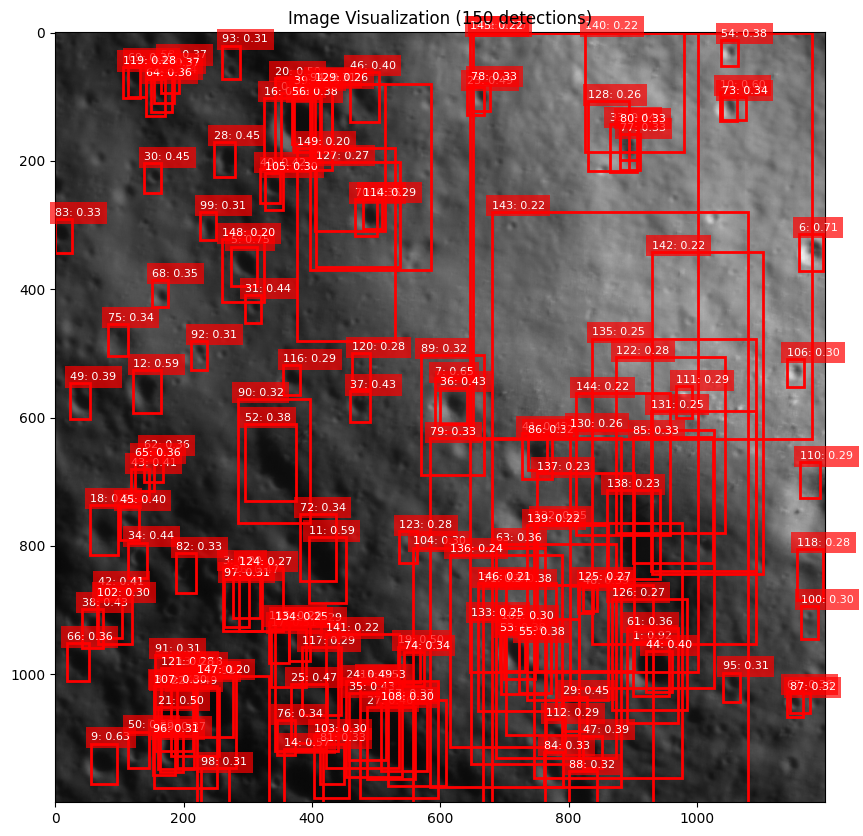

In [622]:
visualize_detection(train_dataset[0][0], output)

In [623]:
dedup_output, iou_matrix = remove_duplicates(output, iou_threshold=-0.1)

In [624]:
torch.tensor(list(range(len(dedup_output["boxes"]))))

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
        54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67])

In [625]:
iou_matrix[52, 10]

tensor(-0.8209, device='cuda:0')

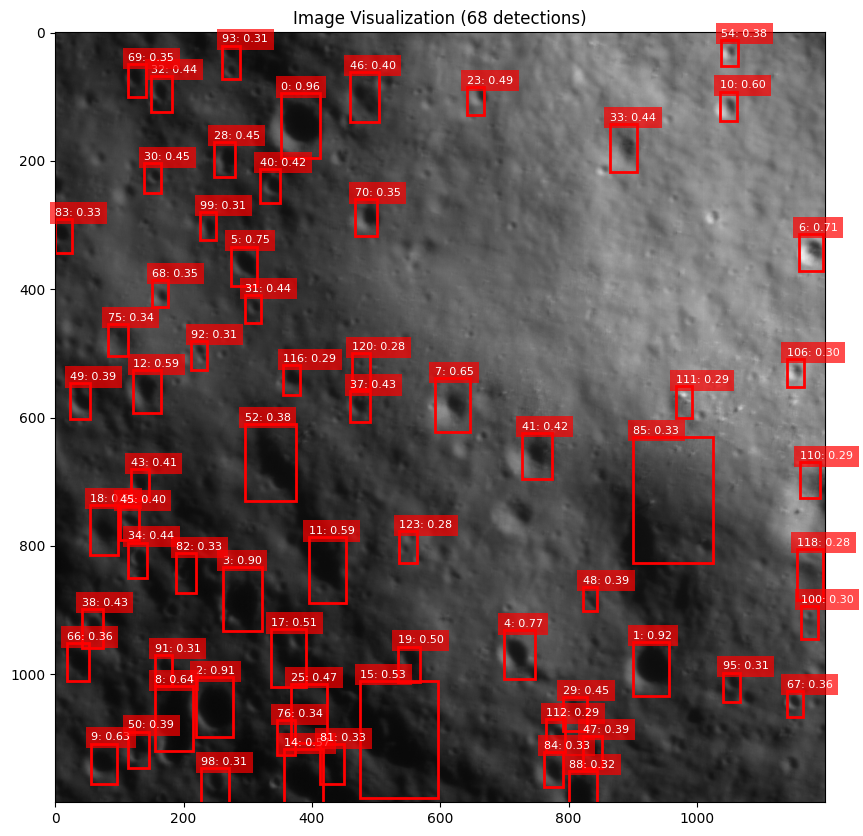

In [626]:
visualize_detection(train_dataset[0][0], dedup_output)

In [627]:
inf_dedup_output = inflate_annots(dedup_output, train_dataset[0][0].shape[1], train_dataset[0][0].shape[2], height_factor=0, width_factor=0.3)

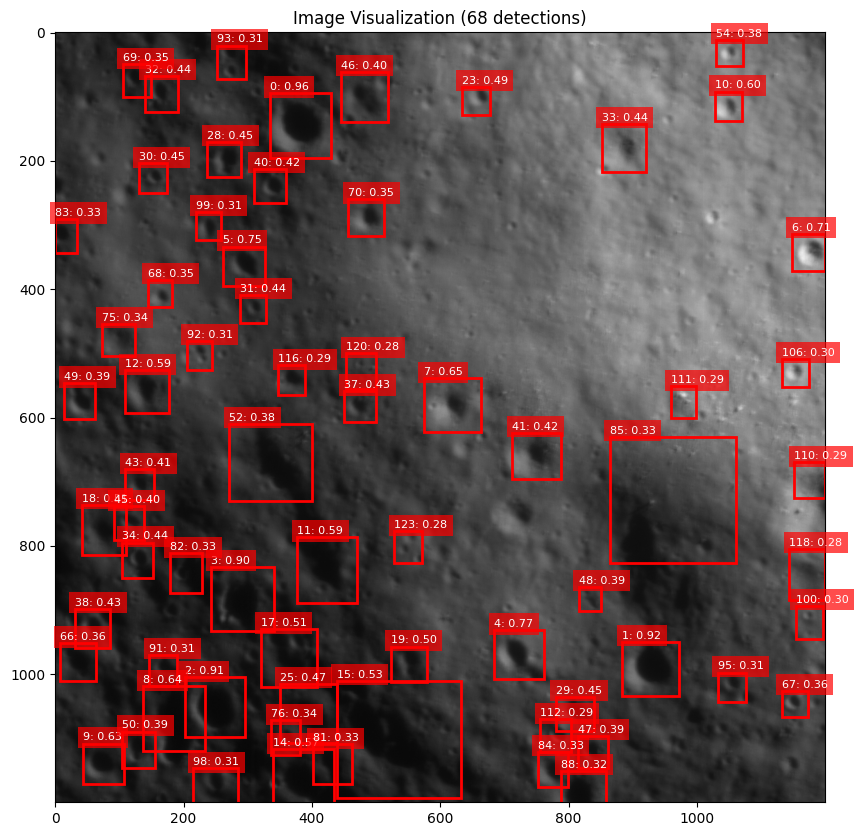

In [628]:
visualize_detection(train_dataset[0][0], inf_dedup_output)